### <b><center>ELG5271: AI for Cybersecurity application <br>Project: Adaptive and Failure-Aware AdversarialDefense for Machine-Learning-Based Intrusion Detection Systems
#### <b><center> Group 4:<br> </b> Karamoko Soumare #:300203291 <br> Elame Olame Mugabo #: <br>Ingrid Fortune Kengfack Zemdem #: <br>Serge Gabin Talom Defo #: <br>

### Project Workflow: 
This project develops an adaptive and failure-aware adversarial defense framework for intrusion detection systems (IDS). The workflow follows a structured pipeline from data preparation to robustness evaluation.

#### Workflow Overview

1. **Data Preparation**  
   Load and preprocess the CIC-IDS2017 dataset, ensuring clean, normalized, and balanced data for training and evaluation.

2. **Baseline Model Training**  
   Train an XGBoost classifier on clean data to establish a reference IDS performance.

3. **Adversarial Attack Generation**  
   Generate adversarial examples using FGSM and PGD to simulate evasion attacks under realistic constraints.

4. **Baseline Evaluation**  
   Evaluate the model on clean and adversarial data using metrics such as F1-score, PR-AUC, and Attack Success Rate (ASR).

5. **Model Behavior Analysis**  
   Compute reliability indicators including prediction confidence, uncertainty, and stability under perturbations.

6. **Failure Detection**  
   Identify unreliable predictions based on low confidence, high uncertainty, or unstable outputs.

7. **Adaptive Defense Mechanism**  
   Dynamically select defense strategies (no defense, FGSM, PGD, retraining) based on model behavior.

8. **Vulnerability-Driven GAN Training**  
   Generate synthetic samples near fragile decision regions to reinforce weak areas of the model.

9. **Iterative Model Refinement**  
   Retrain the model using adversarial and GAN-generated data to improve robustness.

10. **Final Evaluation and Analysis**  
    Compare adaptive defense against static methods and analyze performance across attack scenarios.

#### Pipeline Summary

Data -> Model Training -> Adversarial Attacks -> Evaluation -> 
Behavior Analysis -> Adaptive Defense -> GAN Reinforcement -> Retraining -> Final Evaluation

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score
from xgboost import XGBClassifier

#### 1. **Data Preparation** 
- Load CIC-IDS2017 dataset
- Handle missing values and remove invalid samples
- Encode categorical features (if any)
- Normalize / standardize numerical features
- Split data using stratified k-fold cross-validation (k=5)

In [2]:
# Load the datasets
data1 = pd.read_csv('archive/Monday-WorkingHours.pcap_ISCX.csv')
data2 = pd.read_csv('archive/Tuesday-WorkingHours.pcap_ISCX.csv')
data3 = pd.read_csv('archive/Wednesday-WorkingHours.pcap_ISCX.csv')
data4 = pd.read_csv('archive/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv')
data5 = pd.read_csv('archive/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv')
data6 = pd.read_csv('archive/Friday-WorkingHours-Morning.pcap_ISCX.csv')
data7 = pd.read_csv('archive/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv')
data8 = pd.read_csv('archive/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')

In [3]:
data1.shape, data2.shape, data3.shape, data4.shape, data5.shape, data6.shape, data7.shape, data8.shape

((529918, 79),
 (445909, 79),
 (692703, 79),
 (170366, 79),
 (288602, 79),
 (191033, 79),
 (286467, 79),
 (225745, 79))

In [4]:
# Merge the datasets
data = pd.concat([data1, data2, data3, data4, data5, data6, data7, data8], ignore_index=True)
data.shape
data.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,49188,4,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,49486,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [5]:
# Handle missing values
# Check for missing values and drop rows with missing values
data = data.dropna()

# Replace infinite values with NaN, then drop them
data = data.replace([np.inf, -np.inf], np.nan)
data = data.dropna()

data.shape
data.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,49188,4,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,49486,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [6]:
# Remove invalid values
# Check for invalid values in the 'Label' column and remove rows with invalid values
data.columns = data.columns.str.strip()
data['Label'].value_counts()

Label
BENIGN                        2271320
DoS Hulk                       230124
PortScan                       158804
DDoS                           128025
DoS GoldenEye                   10293
FTP-Patator                      7935
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1956
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

In [7]:
# Encode the labels : BENIGN = 0, ATTACK = 1
data['Label'] = data['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)
data['Label'].value_counts()

Label
0    2271320
1     556556
Name: count, dtype: int64

In [8]:
# Split the data into features and labels
X = data.drop('Label', axis=1)
y = data['Label']

In [9]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [10]:
# Feature normalization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### 2.**Baseline Model Training**
- XGBoost classifier (baseline)
- Train model on clean training data
- Tune hyperparameters (optional: grid search or CV)
- Save trained model


In [11]:
# Xgboost model
model = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    use_label_encoder=False,
    random_state=42
)

model.fit(X_train_scaled, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [12]:
# Train the model and make predictions
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

Precision: 0.9974
Recall: 0.9990
F1-score: 0.9982
ROC-AUC: 1.0000
PR-AUC: 0.9999
False Positive Rate (FPR): 0.0006


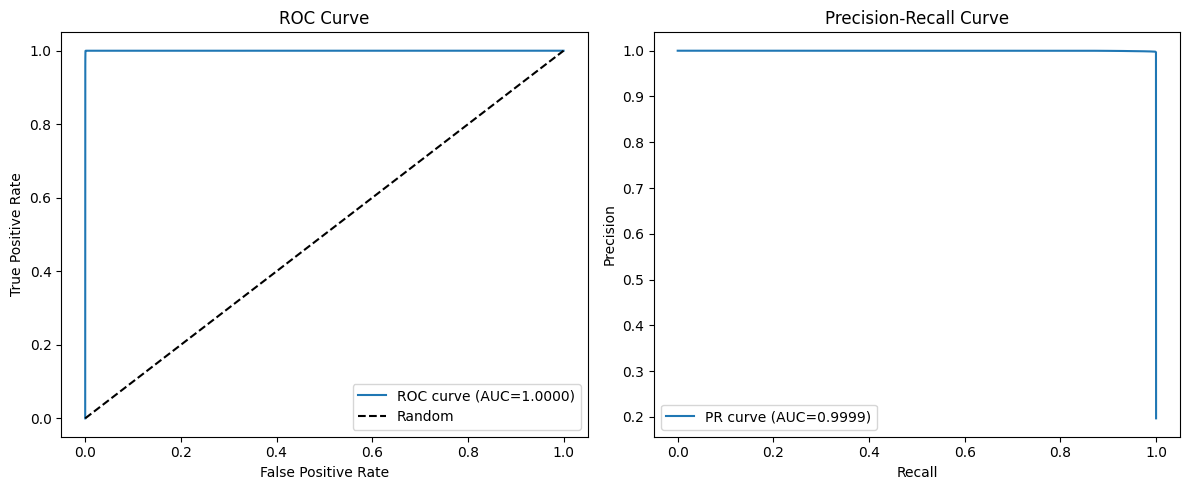

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    454265
           1       1.00      1.00      1.00    111311

    accuracy                           1.00    565576
   macro avg       1.00      1.00      1.00    565576
weighted avg       1.00      1.00      1.00    565576

ROC AUC Score: 0.9999750642303015
Average Precision Score: 0.999894018154631


In [13]:
# Baseline evaluation
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, precision_recall_curve, auc
)

# Point metrics
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, y_proba)

# PR-AUC (area under Precision-Recall curve)
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall_curve, precision_curve)

# False Positive Rate
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
false_positive_rate = fp / (fp + tn)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"ROC-AUC: {auc_roc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")
print(f"False Positive Rate (FPR): {false_positive_rate:.4f}")

# Curves for plotting
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(12, 5))

# ROC Curve
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, label=f"ROC curve (AUC={auc_roc:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

# Precision-Recall Curve
plt.subplot(1, 2, 2)
plt.plot(recall_curve, precision_curve, label=f"PR curve (AUC={pr_auc:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()

plt.tight_layout()
plt.show()
print(classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba))
print("Average Precision Score:", average_precision_score(y_test, y_proba))

#### 4.**Adversarial Attack generation**
- Objective: Simulate adversarial evasion attacks on IDS inputs.

- Attacks Implemented
    - FGSM (single-step attack)
    - PGD (multi-step iterative attack)

- For each input sample `x`:
    1. Compute gradient of loss w.r.t input
    2. Generate adversarial perturbation:
        - FGSM
        - PGD
    3. Enforce feature constraints

In [ ]:
# FGSM implementation: Option 1 - Finite difference approximation of the gradient
def fgsm_attack_xgb(model, X, y, epsilon=0.01, delta=1e-4):
    # Support both numpy arrays and DataFrames
    X_arr = X if isinstance(X, np.ndarray) else X.values
    X_adv = X_arr.copy().astype(float)

    for i in range(len(X_arr)):
        x = X_arr[i].copy()
        grad = np.zeros_like(x)

        # Finite difference approximation of the gradient
        for j in range(len(x)):
            x_plus = x.copy()
            x_plus[j] += delta

            pred1 = model.predict_proba(x.reshape(1, -1))[0][1]
            pred2 = model.predict_proba(x_plus.reshape(1, -1))[0][1]

            grad[j] = (pred2 - pred1) / delta

        # Create adversarial example
        X_adv[i] = x + epsilon * np.sign(grad)

    return X_adv

In [ ]:
# FGSM implementation Option 2 - Using Surrogate neural network to approximate the gradient
# transfer based attack
def fgsm_attack_surrogate(model, X, y, epsilon=0.01, surrogate_epochs=10):
    import torch

    # Support both numpy arrays and DataFrames
    X_arr = X if isinstance(X, np.ndarray) else X.values
    X_arr = X_arr.astype(float)

    # Train a surrogate neural network to approximate the XGBoost model
    surrogate = torch.nn.Sequential(
        torch.nn.Linear(X_arr.shape[1], 64),
        torch.nn.ReLU(),
        torch.nn.Linear(64, 1),
        torch.nn.Sigmoid()
    )

    criterion = torch.nn.BCELoss()
    optimizer = torch.optim.Adam(surrogate.parameters(), lr=0.001)

    X_tensor = torch.tensor(X_arr, dtype=torch.float32)
    y_vals = y.values if hasattr(y, 'values') else y
    y_tensor = torch.tensor(y_vals, dtype=torch.float32).unsqueeze(1)

    for epoch in range(surrogate_epochs):
        surrogate.train()
        optimizer.zero_grad()
        outputs = surrogate(X_tensor)
        loss = criterion(outputs, y_tensor)
        loss.backward()
        optimizer.step()

    # Generate adversarial examples using the surrogate model
    X_adv = X_arr.copy()
    surrogate.eval()

    for i in range(len(X_arr)):
        x_tensor = torch.tensor(X_arr[i], dtype=torch.float32).unsqueeze(0).requires_grad_(True)
        output = surrogate(x_tensor)
        output.backward()
        grad = x_tensor.grad.squeeze().detach().numpy()
        X_adv[i] = X_arr[i] + epsilon * np.sign(grad)

    return X_adv

In [16]:
#FGSM attack using finite difference approximation
X_test_adv_finite = fgsm_attack_xgb(model, X_test_scaled, y_test, epsilon=0.01)
y_pred_adv_finite = model.predict(X_test_adv_finite)
y_proba_adv_finite = model.predict_proba(X_test_adv_finite)[:, 1]

AttributeError: 'numpy.ndarray' object has no attribute 'iloc'

In [ ]:
# FGSm attack using surrogate model
X_test_adv_surrogate = fgsm_attack_surrogate(model, X_test_scaled, y_test, epsilon=0.01, surrogate_epochs=10)
y_pred_adv_surrogate = model.predict(X_test_adv_surrogate)
y_proba_adv_surrogate = model.predict_proba(X_test_adv_surrogate)[:, 1]

In [ ]:
def evaluate_model(y_true, y_pred, y_proba, title="Model Evaluation"):
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc_roc = roc_auc_score(y_true, y_proba)

    precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_proba)
    pr_auc = auc(recall_curve, precision_curve)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    false_positive_rate = fp / (fp + tn)

    print(f"=== {title} ===")
    print(f"Precision:              {precision:.4f}")
    print(f"Recall:                 {recall:.4f}")
    print(f"F1-score:               {f1:.4f}")
    print(f"ROC-AUC:                {auc_roc:.4f}")
    print(f"PR-AUC:                 {pr_auc:.4f}")
    print(f"False Positive Rate:    {false_positive_rate:.4f}")
    print()
    print(classification_report(y_true, y_pred))

    fpr_curve, tpr_curve, _ = roc_curve(y_true, y_proba)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(fpr_curve, tpr_curve, label=f"ROC curve (AUC={auc_roc:.4f})")
    plt.plot([0, 1], [0, 1], "k--", label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve — {title}")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(recall_curve, precision_curve, label=f"PR curve (AUC={pr_auc:.4f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve — {title}")
    plt.legend()

    plt.tight_layout()
    plt.show()

# Evaluate FGSM (finite difference)
evaluate_model(y_test, y_pred_adv_finite, y_proba_adv_finite,
               title="FGSM Attack (Finite Difference)")

# Evaluate FGSM (surrogate model)
evaluate_model(y_test, y_pred_adv_surrogate, y_proba_adv_surrogate,
               title="FGSM Attack (Surrogate Model)")